# 算符表示

In [1]:
import quante as qt

## 基本使用

定义哈密顿量：

$$
    H = \sum_{i = 1}^{L - 1} (\sigma^{x}_{i}\sigma^{x}_{i + 1} + \sigma^{y}_{i} \sigma^{y}_{i + 1} + \frac{1}{2}  \sigma^{z}_{i} \sigma^{z}_{i + 1})
$$

In [3]:
# 定义哈密顿量：
op = qt.generate.operas
L = 4
ham = op.sum(op.xx(i,(i+1)%L) + op.yy(i,(i+1)%L) + 0.5 * op.zz(i,(i+1)%L) for i in range(L-1))
print(ham)

<Oper 0x24e9edb1110
 .data = {'xx': {(0, 1): 1.0, (1, 2): 1.0, (2, 3): 1.0},
          'yy': {(0, 1): 1.0, (1, 2): 1.0, (2, 3): 1.0},
          'zz': {(0, 1): 0.5, (1, 2): 0.5, (2, 3): 0.5}}
 .type = 's'
>


生成基矢

In [8]:
# 生成具有粒子数生活和动量守恒的基矢
basis = qt.generate.basis.spin_basis(L=4, Nup=2, kblock=0)

# 可以查看基矢的个数：
print("空间维数", basis.Ns)

# 可以获得某个基矢在全空间中的表示
state = basis.to_full_space(0)

# 可以可视化全空间的基矢：
print("第 0 个基矢：")
qt.generate.basis.show_spin_basis(state)

空间维数 2
第 0 个基矢：
↑↑↓↓: [0.5+0.j]
↑↓↓↑: [0.5+0.j]
↓↑↑↓: [0.5+0.j]
↓↓↑↑: [0.5+0.j]


生成矩阵

In [10]:
# 获得哈密顿量在给定基矢下的矩阵：
mat = ham.to_matrix(basis)
mat

array([[ 0.125     +0.j,  1.06066017+0.j],
       [ 0.70710678+0.j, -0.375     +0.j]])

计算基态能

In [15]:
# 对角化
engs, eigstates = qt.linalg.eigh(mat, k=1)  # 获得最低能量的本征态
engs

array([-0.875])

计算纠缠

In [ ]:
# 计算纠缠：
entspect = qt.quantity.entanglement_spectrum(eigstates[:,0], L, L//2, basis)  # 纠缠谱
qt.quantity.entropy(entspect)

array(1.20056613)

## 梯子形系统

```
      0   2   4   6
   ---◻---◻---◻---◻---
      |   |   |   |
   ---◻---◻---◻---◻---
      1   3   5   7
```

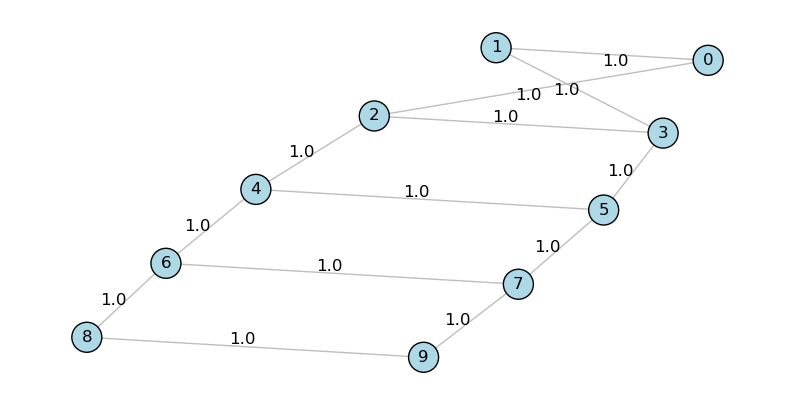

In [27]:
j1, j2, j3 = 1.0, 2.0, 1.0
import quante as qt
op = qt.generate.operas

L = 5

H_Spart = j1 * op.sum(op.xx(2*i,2*i+2) + op.yy(2*i,2*i+2) + op.zz(2*i,2*i+2) for i in range(L-1))
H_Lpart = op.sum(j2 * (op.xx(2*i+1,2*i+3) + op.yy(2*i+1,2*i+3)) + j1 * op.zz(2*i+1,2*i+3) for i in range(L-1))
H_SLpart = j3 * op.sum(op.xx(2*i,2*i+1) + op.yy(2*i,2*i+1) + op.zz(2*i,2*i+1) for i in range(L))

H = H_Spart + H_Lpart + H_SLpart
H.show('zz')

x 方向和 y 方向都是 zzx 相互作用：

In [4]:
j1, j2, j3 = 1.0, 2.0, 1.0

for L in range(4, 10):
    
    H_Spart = j1 * op.sum(op.xx(2*i,2*i+2) + op.yy(2*i,2*i+2) + op.zz(2*i,2*i+2) for i in range(L-1))
    H_Lpart = op.sum(j2 * (op.xx(2*i+1,2*i+3) + op.yy(2*i+1,2*i+3)) + j1 * op.zz(2*i+1,2*i+3) for i in range(L-1))
    H_SLpart = j3 * op.sum(op.xx(2*i,2*i+1) + op.yy(2*i,2*i+1) + op.zz(2*i,2*i+1) for i in range(L))
    
    H = H_Spart + H_Lpart + H_SLpart
    
    basis = qt.generate.basis.spin_basis(L=2*L, Nup=L)
    mat = H.to_matrix(basis, pauli=False, sparse=True)
    gdeng = qt.linalg.eigvalsh(mat, k=1)[0]
    print(f"L={L}, ground state energy={gdeng}")

L=4, ground state energy=-5.149175306097191
L=5, ground state energy=-6.549539316733599
L=6, ground state energy=-7.967781415010528
L=7, ground state energy=-9.379011867020692
L=8, ground state energy=-10.793329596691663
L=9, ground state energy=-12.206480865440017


## 其他使用

与 quspin 的转换

In [2]:
# 对比 quspin 和 quante 的效率（需要在安装 quspin 的环境中运行）
import sys
sys.dont_write_bytecode = True

import quante as qt
import numpy as np
import time

from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian

L = 20
ham = qt.generate.operas.heisenberg_operator(L, j=(1, 1, 1))
ham = ham.expandxy(pauli=False)
quspin_basis = spin_basis_1d(L=L, pauli=0)
lis = ham.quspin_form()

t = time.time()
mat3 = hamiltonian(lis, [], basis=quspin_basis, check_symm=False, check_herm=False, dtype=np.float64).static
print("quspin time: ", time.time()-t)

basis = qt.generate.basis.spin_basis(L=L)
t = time.time()
mat1 = ham.to_matrix(basis, sparse=True)
print("quante time: ", time.time()-t)


print("diff: ",qt.linalg.norm(mat1 - mat3))

quspin time:  2.2405903339385986
quante time:  0.455899715423584
diff:  0.0


其他方法的效率对比

In [1]:
# 没有对称性时,快速生成矩阵元
# 方法1 正常 cpu 方法
import time
import quante as qt
from quante.tensor.automata import get_sparse_matrix

basis = qt.generate.basis.spin_basis(24)
ham = qt.generate.operas.heisenberg_operator(24)
ham = ham.expandxy(False)

t = time.time()
ham.to_matrix(basis, sparse=True)
print("cpu 并行计算需要的时间:", time.time()-t)

t = time.time()
mat = get_sparse_matrix(24, *ham.split_data(), pauli=False)  # 只能计算无对称性的
print("利用 automata 需要的时间:", time.time()-t)

from quante.torch_utils.symmetry.basis import to_matrix_cuda
eachterm, hascomplex = ham._convert_to_quick_form()
t = time.time()
mat = to_matrix_cuda(basis, eachterm, hascomplex)  # 只能计算无对称性的
print("gpu 计算需要的时间:", time.time()-t)

t = time.time()
mat = get_sparse_matrix(24, *ham.split_data(), pauli=False, usecuda=True)
print("同时利用 gpu 和 automata 需要的时间:", time.time()-t)  # 只能计算无对称性的

cpu 并行计算需要的时间: 9.864118337631226
利用 automata 需要的时间: 7.72164249420166


e:\hzhu\onedrive\python_library\quante\torch_utils\symmetry\basis.py:26: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  return tc.sparse_csr_tensor(Bp_torch, Bj_torch, Bx_torch, (n_row, n_row))


gpu 计算需要的时间: 4.407119512557983
同时利用 gpu 和 automata 需要的时间: 2.608093500137329


生成矩阵的难点在于, 稀疏矩阵的加法, 它无法利用并行加速

automata 之所以更快是因为, 它最小化了大型稀疏矩阵加法的次数

## SU(2) 工具

下面函数中参数中 `jmblock = (J, m)`

`J` 可取的值，可取 `L/2`, `L2/2-1`, ... `0`，`m` 可取的值为 `5`, `4`, `3`, `2`, `1`, `0`, `-1`, `-2`, `-3`, `-4`, `-5`

`dim` 表示子空间的维数，`num` 表示子空间重复的次数，因而：

In [ ]:
L = 4
basis = qt.generate.basis.spin_basis(L, jmblock=(2, 2))

basis.print_dims(L)

   J  |   num  |   dim   
-----------------------
  2.0 |   5    |  1
  1.0 |   3    |  3
  0.0 |   1    |  2
-----------------------
note: \sum num * dim = 2^L


可以与普通的 basis 一样生成矩阵，但目前采用投影矩阵的方法，效率低

In [ ]:
ham = qt.generate.operas.heisenberg_operator(L)
mat = ham.to_matrix(basis)
mat.shape, mat

((1, 1), array([[0.75]]))

In [ ]:
basis_ = qt.generate.basis.spin_basis(L)
mat_ = ham.to_matrix(basis_)
qt.linalg.eigvalsh(mat_).reshape(4,-1)

array([[-1.6160254 , -0.95710678, -0.95710678, -0.95710678],
       [-0.25      , -0.25      , -0.25      ,  0.1160254 ],
       [ 0.45710678,  0.45710678,  0.45710678,  0.75      ],
       [ 0.75      ,  0.75      ,  0.75      ,  0.75      ]])

可以看到 0.75 确实重复的 5 次

In [ ]:
basis = qt.generate.basis.spin_basis(L, jmblock=(1, 1))
mat = ham.to_matrix(basis)
qt.linalg.eigvalsh(mat)

array([-0.95710678, -0.25      ,  0.45710678])

对比可以看到 这三个数每个都重复了三次

验证每个基矢都是 $J^2$ 的本征态

In [ ]:
vec = basis.to_full_space(1)  # 第二个基矢，任何一个基矢都满足
# 这个向量是 J^2 的本征态

op = qt.generate.operas
op_Jx = op.sum(op.x(i) for i in range(L))
op_Jy = op.sum(op.y(i) for i in range(L))
op_Jz = op.sum(op.z(i) for i in range(L))
op_J2 = op_Jx**2 + op_Jy**2 + op_Jz**2

basis_ = qt.generate.basis.spin_basis(L)
mat_J2 = op_J2.to_matrix(basis_)

import numpy as np
np.real_if_close(mat_J2 @ vec - 1*(1+1)*vec)  # 这个向量是 J^2 的本征态

array([ 0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

验证每个基矢都是 $J_z$ 的本征态

In [ ]:
basis_ = qt.generate.basis.spin_basis(L)
mat_Jz = op_Jz.to_matrix(basis_)

import numpy as np
np.real_if_close(mat_Jz @ vec - 1*vec)  # 这个向量是 Jz 的本征态

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])